#  Exploración del espacio de estados de un cúbit

La Esfera de Bloch es una representación geométrica fundamental en la computación cuántica que permite visualizar el estado de un sistema de un solo cúbit. A diferencia de un bit clásico, que solo puede tomar valores discretos (0 o 1), un cúbit puede hallarse en una superposición coherente de ambos estados, representándose como un punto sobre la superficie de una esfera de radio unidad.

## Objetivos de la actividad:

- **Representación Geométrica**: Desarrollar una herramienta visual que mapee estados cuánticos complejos en un espacio tridimensional (x, y, z).

- **Simulación de Puertas Cuánticas**: Visualizar el impacto de diversos operadores unitarios como Hadamard, Paulis, rotaciones de fase y raíces cuadradas sobre el vector de estado.

 - **Interactividad**: Implementar una interfaz que permita modificar los parámetros de entrada (Theta y Phi) para observar en tiempo real la evolución del sistema.

Cualquier estado puro de un cúbit puede escribirse mediante la combinación lineal de los estados base, donde Theta representa el ángulo polar y Phi la fase relativa o ángulo azimutal. El propósito de este Trabajo visualizar estas operaciones matemáticas de una forma intuitiva y dinámica.

## Instalación de dependencias.
*Es importante reiniciar el Kernel tras las instalación*

In [2]:
%pip install qiskit qiskit-aer matplotlib numpy ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [3]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import ipywidgets as widgets
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np 

%matplotlib inline

## Visualización de Esfera de Bloch
Implementación manual mediante Matplotlib para representar estados cuánticos en el espacio 3D sin depender de funciones predefinidas de Qiskit.

In [4]:
def plot_bloch_from_scratch(x, y, z, title="Cúbit en la Esfera de Bloch"):
    """
    Dibuja una esfera de Bloch desde cero usando matplotlib, representando
    cualquier estado cuántico dado por sus coordenadas cartesianas (x,y,z).
    
    Esta función NO utiliza librerías cuánticas de visualización.
    
    Args:
        x, y, z (float): Coordenadas del estado cuántico (deben cumplir x^2+y^2+z^2 = 1).
        title (str): Título del gráfico.
    """
    
    # --- 1. Configuración del Entorno 3D ---
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.set_aspect('equal') # Importante para que no parezca un huevo

    # --- 2. Creación de la Esfera Traslúcida (Superficie) ---
    # Usamos coordenadas esféricas para generar la malla (mesh)
    u = np.linspace(0, 2 * np.pi, 100) # Ángulo azimutal (phi)
    v = np.linspace(0, np.pi, 100)     # Ángulo polar (theta)
    
    # Ecuaciones paramétricas de la esfera
    x_sphere = np.outer(np.cos(u), np.sin(v))
    y_sphere = np.outer(np.sin(u), np.sin(v))
    z_sphere = np.outer(np.ones(np.size(u)), np.cos(v))

    # Dibujar superficie: wireframe es más eficiente que plot_surface para traslúcidos
    ax.plot_wireframe(x_sphere, y_sphere, z_sphere, color='gray', alpha=0.1, linewidth=0.5)

    # --- 3. Creación de los Ejes de Referencia (X, Y, Z) ---
    # Los ejes cruzan el origen (0,0,0) desde -1.1 a 1.1 para sobresalir un poco
    limit = 1.1
    
    # Eje Z (Notación: |0> y |1>)
    ax.plot([0, 0], [0, 0], [-limit, limit], color='black', linestyle='--', linewidth=1)
    # Eje X (Notación: |+> y |->)
    ax.plot([-limit, limit], [0, 0], [0, 0], color='black', linestyle='--', linewidth=1)
    # Eje Y (Notación: |i+> y |i->)
    ax.plot([0, 0], [-limit, limit], [0, 0], color='black', linestyle='--', linewidth=1)

    # Etiquetar los polos y ejes
    # Usamos Mathtext de Matplotlib (símil a LaTeX)
    ax.text(0, 0, limit + 0.1, r'$|0\rangle$', color='black', fontsize=12, ha='center')
    ax.text(0, 0, -limit - 0.2, r'$|1\rangle$', color='black', fontsize=12, ha='center')
    ax.text(limit + 0.1, 0, 0, r'$x$', color='red', fontsize=12, ha='center')
    ax.text(0, limit + 0.1, 0, r'$y$', color='green', fontsize=12, ha='center')

    # --- 4. Visualización del Círculo Ecuatorial (Opcional pero ayuda visualmente) ---
    theta_eq = np.linspace(0, 2*np.pi, 100)
    ax.plot(np.cos(theta_eq), np.sin(theta_eq), 0, color='gray', alpha=0.3)

    # --- 5. Graficar el Vector de Estado ---
    # Primero, el punto en la superficie
    ax.scatter([x], [y], [z], color='blue', s=100, label='Estado actual')
    
    # Segundo, la flecha (vector) desde el origen usando 'quiver'
    # 'quiver(x_origin, y_origin, z_origin, x_dir, y_dir, z_dir)'
    ax.quiver(0, 0, 0, x, y, z, color='blue', length=1.0, normalize=True, arrow_length_ratio=0.1, linewidth=2)

    # --- 6. Toques Finales ---
    ax.set_title(title)
    
    # Eliminar los ticks (marcas numéricas) de los ejes para limpieza
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    
    # Establecer límites de visualización
    ax.set_xlim([-limit, limit])
    ax.set_ylim([-limit, limit])
    ax.set_zlim([-limit, limit])
    
    # Ocultar el panel de fondo 3D por defecto para limpieza
    ax.grid(False)
    # ax.axis('off') # Si quieres eliminar completamente la caja del cubo

    plt.show()


## Integración con Qiskit

Esta sección gestiona la lógica cuántica y la transformación de datos para la simulación.

### Componentes del Sistema:

* **Preparación del Estado (`crear_estado_qubit`):** Implementa la parametrización matemática de un cúbit en la esfera de Bloch.
* **Gestión del Circuito (`crear_quantum_circuit`):** Utiliza la librería **Qiskit** para instanciar el circuito cuántico.
* **Manipulación y Evolución (`obtener_estado_final`):** Ejecuta las puertas cuánticas solicitadas (H, Paulis, S, T, V) sobre el circuito.
* **Proyección Geométrica (`get_bloch_coordinates`):** Transforma el vector de estado (espacio de Hilbert) a coordenadas cartesianas $(x, y, z)$ mediante los valores esperados de los operadores de Pauli.
* **Visualización (`visualizar_estado`):** Actúa como interfaz entre el motor lógico y el motor de renderizado 3D manual.
* **Ejecutor de la simulación (simular_qbit):**  Centraliza el flujo de trabajo siguiendo un patrón de pipeline de datos. Esta función coordina la ingesta de parámetros, la transformación cuántica, el mapeo de coordenadas y el renderizado final de la esfera.

In [5]:
def visualizar_estado(theta_deg, phi_deg, titulo=""):
    """
    Toma ángulos en grados, los convierte a coordenadas cartesianas 
    y utiliza la función de dibujo manual para representar el punto en la esfera.
    """
    # Conversión a radianes
    theta = np.radians(theta_deg)
    phi = np.radians(phi_deg)
    
    # Cálculo de coordenadas cartesianas desde ángulos esféricos
    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(theta)
    
    # Llamada a la función de dibujo
    plot_bloch_from_scratch(x, y, z, title=titulo)

def get_bloch_coordinates(statevector):
    """
    Calcula los valores de expectación de los observables de Pauli (X, Y, Z) 
    para mapear un Statevector de Qiskit al espacio tridimensional de la esfera.
    """
    # Se extraen las amplitudes alpha (para |0>) y beta (para |1>)
    alpha = statevector.data[0]
    beta = statevector.data[1]
    
    # x = <psi|X|psi>, y = <psi|Y|psi>, z = <psi|Z|psi>
    x = 2 * np.real(np.conj(alpha) * beta)
    y = 2 * np.imag(np.conj(alpha) * beta)
    z = np.abs(alpha)**2 - np.abs(beta)**2
    
    return x, y, z

def crear_estado_qubit(theta_deg, phi_deg):
    """
    Genera un vector de estado normalizado aplicando la parametrización:
    |psi> = cos(theta/2)|0> + e^(i*phi)sin(theta/2)|1>
    """
    # Normalización de ángulos para evitar desbordamientos y conversión a radianes
    theta_rad = np.radians(theta_deg % 360)
    phi_rad = np.radians(phi_deg % 360)
    
    # Amplitudes complejas
    alpha = np.cos(theta_rad / 2)
    beta = np.exp(1j * phi_rad) * np.sin(theta_rad / 2)
    
    return Statevector([alpha, beta])

def crear_quantum_circuit(estado_inicial):
    """
    Instancia un QuantumCircuit de Qiskit de 1 qbit y lo inicializa
    en el estado proporcionado.
    """
    qc = QuantumCircuit(1)
    qc.initialize(estado_inicial, 0)
    return qc

def obtener_estado_final(theta_deg, phi_deg, qc, puerta):
    """
    Aplica la puerta cuántica seleccionada (si existe) sobre el circuito 
    y extrae el Statevector resultante de la simulación.
    """
    if puerta is not None:
        puerta(0)
    
    # Extraer el vector de estado final del circuito
    estado_final = Statevector.from_instruction(qc)
    return estado_final
    
def simular_qbit(theta_deg, phi_deg, nombre_puerta):
    """ 
    Realiza la creación del estado, la ejecución del circuito cuántico,
    la extracción de resultados y la representación gráfica final.
    """
    # Llamada a la función de creación de estado
    estado_inicial = crear_estado_qubit(theta_deg, phi_deg)
    qc = crear_quantum_circuit(estado_inicial)
    
    # Lógica de manipulación de puertas
    puertas = {
        'H': qc.h, 'X': qc.x, 'Y': qc.y, 'Z': qc.z,
        'S': qc.s, 'Sdg': qc.sdg, 'T': qc.t, 'Tdg': qc.tdg, 
        'V': qc.sx, 'Vdg': qc.sxdg, 'I': qc.id
    }
    
    # 4. Obtención del estado final
    estado_final = obtener_estado_final(theta_deg, phi_deg, qc, puertas.get(nombre_puerta))
    # 5. Extracción de coordenadas y visualización
    x, y, z = get_bloch_coordinates(estado_final)
    
    titulo_grafico = (f"Entrada: θ={theta_deg % 360}°, φ={phi_deg % 360}°\n"
                     f"Estado final tras aplicar: {nombre_puerta}")
    
    plot_bloch_from_scratch(x, y, z, title=titulo_grafico)
    

##  Resultados y Casos de Prueba

En esta sección se ejecutan diversas simulaciones para validar el comportamiento de las puertas cuánticas y la precisión del motor de renderizado. Los casos seleccionados cubren las rotaciones principales en los ejes X, Y y Z.
Pruebas de Validación:

- Puerta X: Transición de (∣0⟩) a (∣1⟩).

- Puerta T: Rotación de π/4 sobre el ecuador de la esfera.

- Puerta V: Rotación de 90° que sitúa el vector en el eje Y.

- Puerta S adjunta: Validación de rotaciones negativas para regresar a estados anteriores.

- Puerta I: Comprobación de que el sistema mantiene el mismo estado.

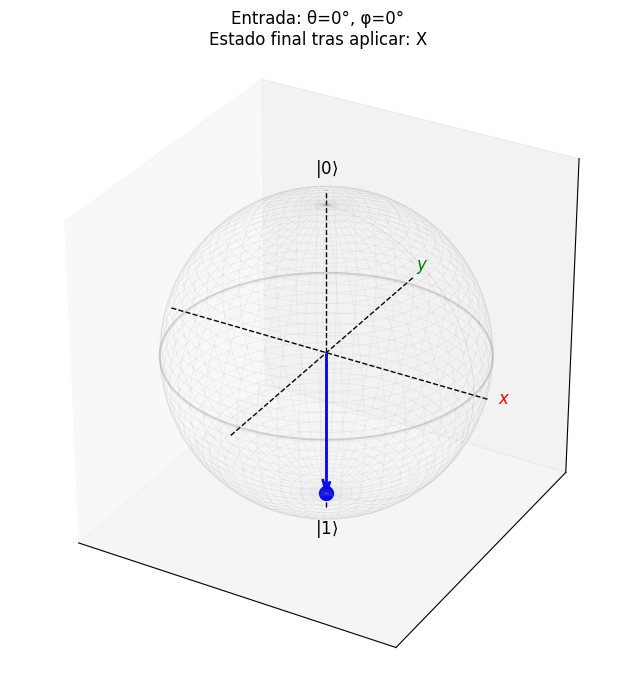

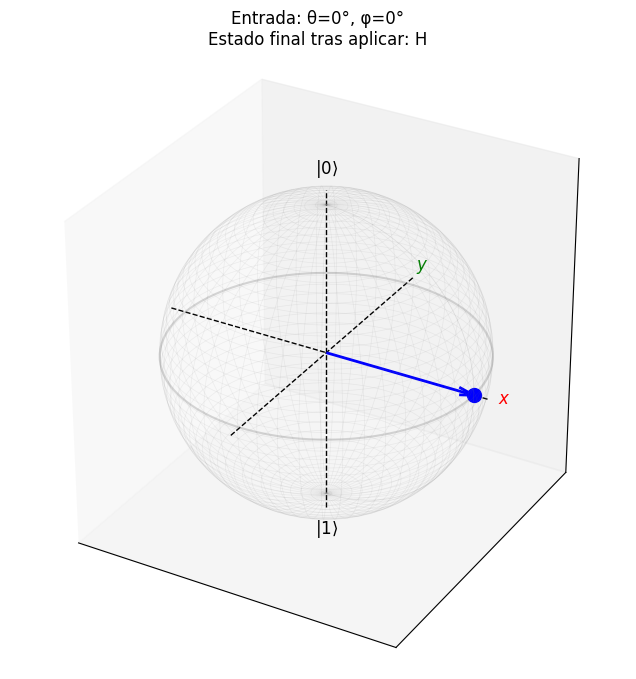

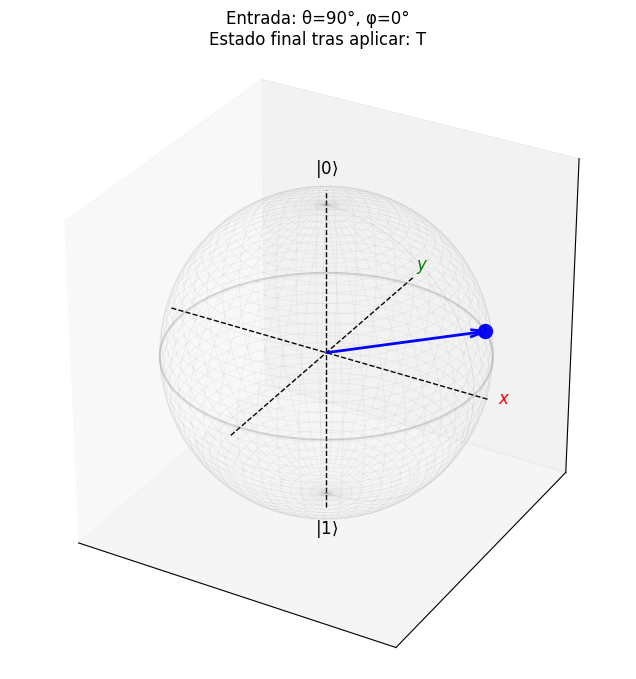

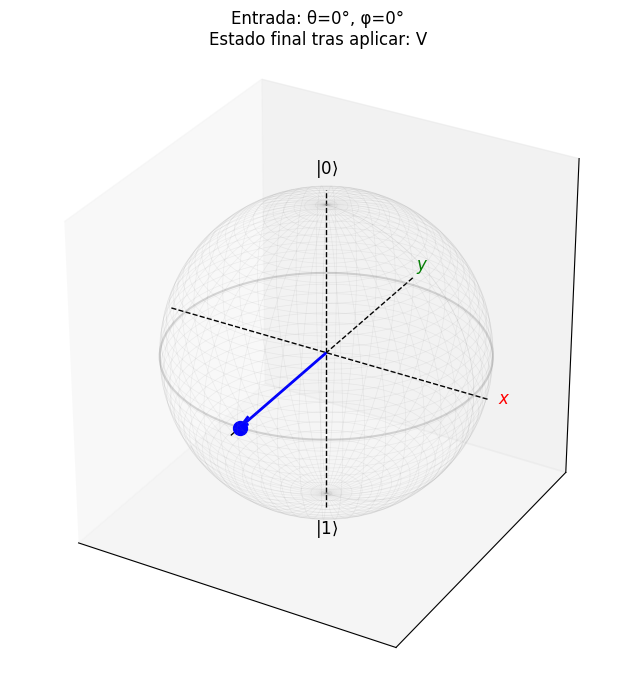

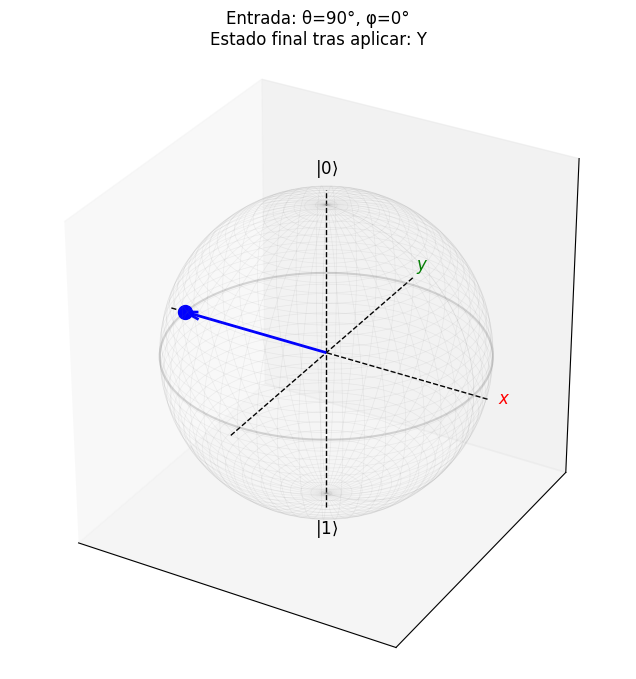

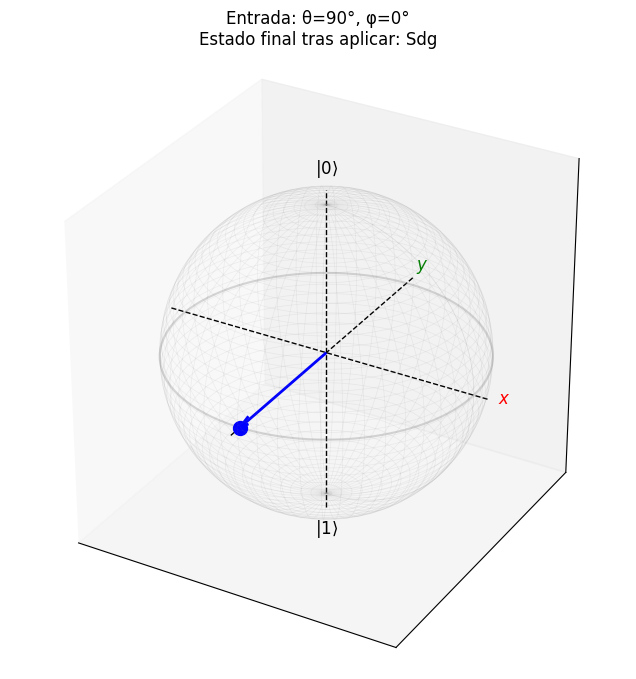

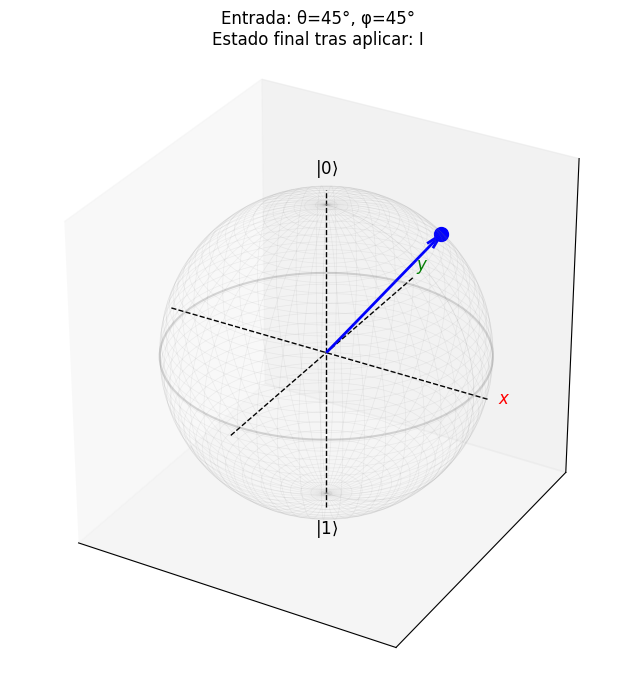

In [10]:
# Cambio de base: de |0> a |1> usando la puerta Pauli-X
simular_qbit(0, 0, "X")

# Creación de superposición (H) partiendo del estado fundamental
simular_qbit(0, 0, "H")

# Rotación de fase (T) en el ecuador: desplaza el vector 45 grados en Phi
simular_qbit(90, 0, "T")

# Puerta V: Rotación de 90° sobre el eje X (lleva |0> al eje Y+)
simular_qbit(0, 0, "V")

# Rotación sobre el eje Y: Puerta Y aplicada a un estado en el eje X
simular_qbit(90, 0, "Y")

# Uso de puerta S adjunta: hace una rotación de 270° en Z
simular_qbit(90, 0, "Sdg")

# Uso de puerta Identidad: el sistema mantiene el mismo estado
simular_qbit(45, 45, "I")

In [6]:
# Controles
theta_input = widgets.FloatText(value=0.0, description='Theta (°):')
phi_input = widgets.FloatText(value=0.0, description='Phi (°):')
selector_puerta = widgets.Dropdown(
    options=['I', 'H', 'X', 'Y', 'Z', 'S', 'Sdg', 'T', 'Tdg', 'V', 'Vdg'],
    value='I',
    description='Puerta:',
)

# Renderizado
widgets.interact(simular_qbit, 
                 theta_deg=theta_input, 
                 phi_deg=phi_input, 
                 nombre_puerta=selector_puerta)

interactive(children=(FloatText(value=0.0, description='Theta (°):'), FloatText(value=0.0, description='Phi (°…

<function __main__.simular_qbit(theta_deg, phi_deg, nombre_puerta)>